In [1]:
import pandas as pd
import numpy as np
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('seaborn-whitegrid')
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils import shuffle

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load Data

In [3]:
filename = 'OptionData.csv'
df = pd.read_csv(filename)
df.head()

,Vol,Spot,T,CallValue,CallDelta,CallGamma,CallTheta,CallVega,CallRho,PutValue,PutDelta,PutGamma,PutTheta,PutVega,PutRho
0,0.680514,186.600738,4.307459,123.610440,0.874486,7.833258e-04,-6.315583,79.951649,170.442793,37.009702,-1.255144e-01,7.833258e-04,-6.315583,79.951649,-260.303063
1,0.831512,160.023861,3.712993,107.540359,0.863145,8.547510e-04,-7.566873,67.577462,113.556028,47.516498,-1.368551e-01,8.547510e-04,-7.566873,67.577462,-257.743254
2,0.573235,145.506848,4.325777,80.222407,0.818773,1.519029e-03,-5.284063,79.749793,168.336206,34.715559,-1.812270e-01,1.519029e-03,-5.284063,79.749793,-264.241509
3,0.157122,160.886209,1.181271,60.903513,0.997948,2.362467e-04,-0.075482,1.134982,117.716569,0.017304,-2.052387e-03,2.362467e-04,-0.075482,1.134982,-0.410497
4,0.098693,183.300264,1.544350,83.300266,1.000000,6.548985e-08,-0.000011,0.000335,154.434882,0.000001,-2.837679e-07,6.548985e-08,-0.000011,0.000335,-0.000082


### Split Data

In [4]:
train_df = df[:-20000]
test_df = df[-20000:]

### Prepare the Training Data

In [5]:
def prepareData(data_df):
    drop_list = ['CallValue', 'CallDelta', 
                'CallGamma', 'CallTheta', 'CallVega', 
                'CallRho', 'PutValue', 'PutDelta', 
                'PutGamma', 'PutTheta', 'PutVega', 'PutRho']

    input_data = data_df.copy(deep=True)
    input_data = input_data.drop(drop_list, axis=1)
    
    call_input_data = input_data.copy(deep=True)
    put_input_data = input_data.copy(deep=True)
    
    call_input_data['PutCall'] = 1
    put_input_data['PutCall'] = 0
    
    frames_list = [call_input_data, put_input_data]
    X = pd.concat(frames_list)
    
    label_call = data_df['CallValue'].tolist()
    label_put = data_df['PutValue'].tolist()
    
    y = label_call + label_put
    y = np.array(y)
    
    return X, y

In [6]:
X, y = prepareData(train_df)

### Prepare the Test Data

In [7]:
X_test, y_test = prepareData(test_df)

### Build Model

In [8]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(4, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [9]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs):
    train_errors = []
    test_errors = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0

        # Training
        for batch_X, batch_y in train_loader:
            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs.squeeze(), batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)
        train_errors.append(train_loss)
        
        # Evaluation on test set
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                loss = loss_fn(outputs.squeeze(), batch_y)
                test_loss += loss.item() * batch_X.size(0)

        test_loss /= len(test_loader.dataset)
        test_errors.append(test_loss)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} \
            - Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}")

    history = dict()
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    return history

In [10]:
no_epochs = 100

### No Scaling

In [11]:
X_noscale, y_noscale = shuffle(X, y, random_state=42)

In [12]:
model_noscale = NeuralNetwork().to(device)

In [13]:
optimizer = optim.RMSprop(model_noscale.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [14]:
train_x = torch.Tensor(X_noscale.to_numpy()).to(device)
train_y = torch.Tensor(y_noscale).to(device)
train_dataset = TensorDataset(train_x, train_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10000, 
                                           shuffle=True, drop_last=True)

test_x = torch.Tensor(X_test.to_numpy()).to(device)
test_y = torch.Tensor(y_test).to(device)
test_dataset = TensorDataset(test_x, test_y)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, 
                                          shuffle=False, drop_last=True)

In [15]:
noscale_dict = train_model(model_noscale, train_loader, test_loader,
                           loss_fn, optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

### Standard Scaling

In [31]:
standard_scalar = StandardScaler()
X_standard = X.copy(deep=True)
X_standard[['Vol', 'Spot', 'T']] = standard_scalar.fit_transform(X_standard[['Vol', 'Spot', 'T']])

In [32]:
X_test_standard = X_test.copy(deep=True)
X_test_standard[['Vol', 'Spot', 'T']] = standard_scalar.transform(X_test_standard[['Vol', 'Spot', 'T']])
X_standard, y_standard = shuffle(X_standard, y, random_state=42)

In [33]:
model_standard = NeuralNetwork().to(device)

In [34]:
optimizer = optim.RMSprop(model_standard.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [35]:
train_x = torch.Tensor(X_standard.to_numpy()).to(device)
train_y = torch.Tensor(y_standard).to(device)
train_dataset = TensorDataset(train_x, train_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10000, 
                                           shuffle=True, drop_last=True)

test_x = torch.Tensor(X_test_standard.to_numpy()).to(device)
test_y = torch.Tensor(y_test).to(device)
test_dataset = TensorDataset(test_x, test_y)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, 
                                          shuffle=False, drop_last=True)

In [36]:
standardscale_dict = train_model(model_standard, train_loader, test_loader,
                           loss_fn, optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

### MaxMin Scaling

In [22]:
minmax_scalar = MinMaxScaler()
X_minmax = X.copy(deep=True)
X_minmax[['Vol', 'Spot', 'T']] = minmax_scalar.fit_transform(X_minmax[['Vol', 'Spot', 'T']])

In [23]:
X_test_minmax = X_test.copy(deep=True)
X_test_minmax[['Vol', 'Spot', 'T']] = minmax_scalar.transform(X_test_minmax[['Vol', 'Spot', 'T']])
X_minmax, y_minmax = shuffle(X_minmax, y, random_state=42)

In [24]:
model_maxmin = NeuralNetwork().to(device)

In [25]:
optimizer = optim.RMSprop(model_maxmin.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [26]:
train_x = torch.Tensor(X_minmax.to_numpy()).to(device)
train_y = torch.Tensor(y_minmax).to(device)
train_dataset = TensorDataset(train_x, train_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10000, 
                                           shuffle=True, drop_last=True)

test_x = torch.Tensor(X_test_minmax.to_numpy()).to(device)
test_y = torch.Tensor(y_test).to(device)
test_dataset = TensorDataset(test_x, test_y)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, 
                                          shuffle=False, drop_last=True)

In [27]:
maxminscale_dict = train_model(model_maxmin, train_loader, test_loader,
                               loss_fn, optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

### Plot the training loss

In [37]:
epochs = range(1, no_epochs + 1)

In [38]:
loss_values_noscale = noscale_dict['train_loss']
loss_values_standard = standardscale_dict['train_loss']
loss_values_minmax = maxminscale_dict['train_loss']

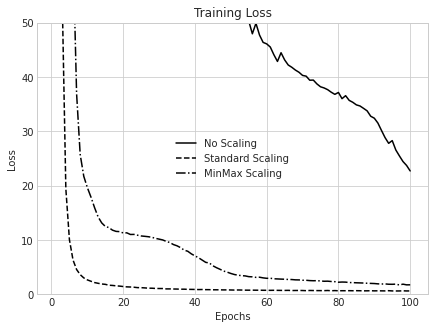

In [39]:
plt.figure(figsize=(7,5)) 
plt.plot(epochs, loss_values_noscale, color='k', linestyle='-', label = 'No Scaling')
plt.plot(epochs, loss_values_standard, color='k', linestyle='--', label = 'Standard Scaling')
plt.plot(epochs, loss_values_minmax, color='k', linestyle='-.', label = 'MinMax Scaling')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0,50)
plt.legend()
plt.savefig('TestScaling.png', dpi=300, bbox_inches='tight')